#Exercício 3.1 atividade 3 - Lucas Fiuza Garcia

####Objetivo: Baseado em uma imagem com várias moedas (de 5, 10 e 25 centavos), identificar, classificar e somar os valores delas utilizando técnicas de processamento de imagens para obter o valor total presente na imagem.

##Preparação

###Importando bibliotecas

In [114]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import urllib.request
import requests
import os
import cv2

###Download das Imagens

In [115]:
def download_image(url:str) -> str:
    filename = os.path.basename(url)

    if os.path.exists(filename):
        return filename

    response = requests.get(url)

    with open(filename, mode="wb") as file:
        file.write(response.content)

    return filename

In [116]:
url_base = r"https://raw.githubusercontent.com/UNICAMP-EA979/EA979-Recursos/main/imgs/{value}.jpg"
values = [75, 80, 95]

filenames = []

for value in values:
    url = url_base.format(value=value)
    filename = download_image(url)
    filenames.append(filename)

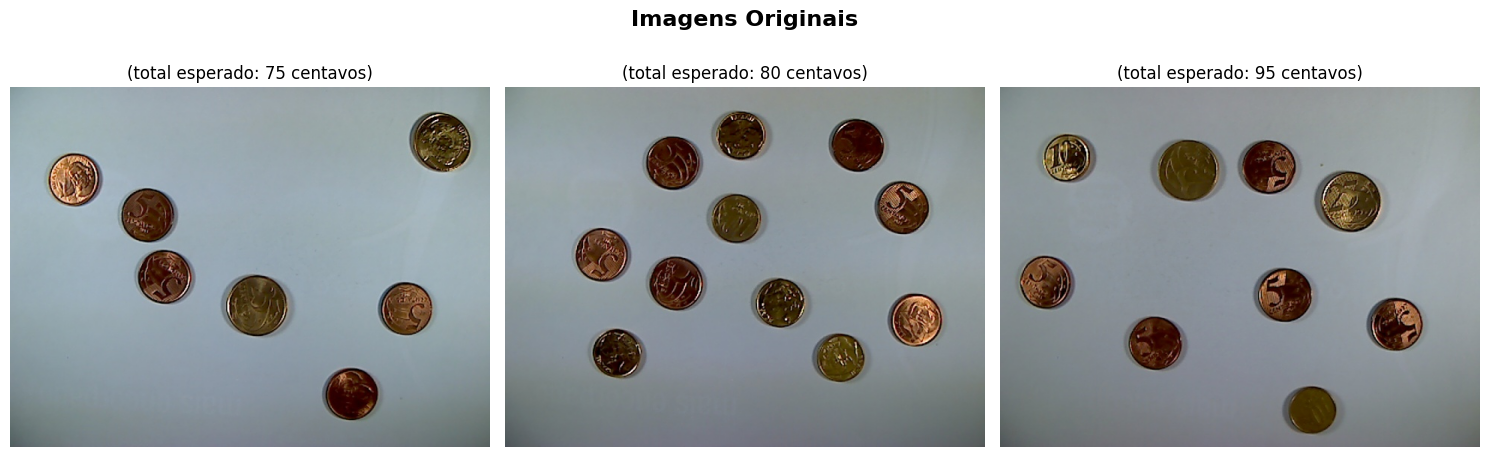

In [117]:
fig, axs = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Imagens Originais', fontsize=16, fontweight='bold')

for i, file in enumerate(filenames):
    img = mpimg.imread(file)
    axs[i].imshow(img)
    axs[i].set_title(f'(total esperado: {values[i]} centavos)', fontsize=12)
    axs[i].axis('off')

plt.tight_layout()
plt.show()

##Demonstração

###Para essa demonstração, escolha uma das três imagens disponíveis alterando o valor abaixo (de 0 a 2)

In [118]:
numero_da_imagem = 1

###Etapa 1 - Conversão para escala de cinza


Para representar cores, as imagens normalmente são divididas em 3 bandas: **R** (red), **G** (Green) e **B** (Blue), representando as intensidades de vermelho, verde e azul respectivamente em cada pixel da imagem.

Para facilitar o processamento, o primeiro passo desta demonstração é converter a imagem para a escala de cinza, obtendo um único canal para representar as intensidades dos pixels.

Para isso podemos fazer a média das 3 bandas, mas como o olho humano tem uma sensibilidade diferente para cada cor (sendo bem mais sensível à verde), a média usada é ponderada:

$$Gray = 0.3 R + 0.59 G + 0.11 B$$

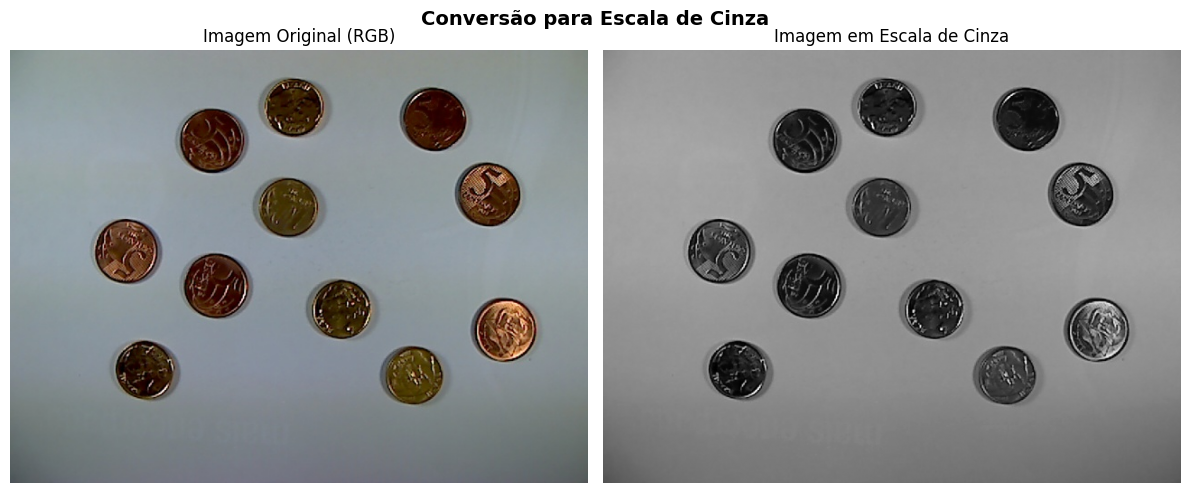

In [119]:
img_demo = mpimg.imread(filenames[numero_da_imagem]).astype('uint8')
img_gray_demo = np.uint8(0.3 * img_demo[:,:,0] + 0.59 * img_demo[:,:,1] + 0.11 * img_demo[:,:,2])


#-------------------------------Plotando----------------------------------------
fig, axs = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Conversão para Escala de Cinza', fontsize=14, fontweight='bold')

axs[0].imshow(img_demo)
axs[0].set_title('Imagem Original (RGB)')
axs[0].axis('off')

axs[1].imshow(img_gray_demo, cmap='gray')
axs[1].set_title('Imagem em Escala de Cinza')
axs[1].axis('off')

plt.tight_layout()
plt.show()


###Etapa 2 - Limiarização

Para podermos classificar as moedas, primeiro precisamos separá-las do fundo da imagem. para isso, utilizamos uma técnica de limiarização (thresholding) para tornar a imagem em uma imagem preta e branca onde cores abaixo do limiar viram preto (o fundo) e o resto, branco (são as moedas).

as imagens são mais escuras que o fundo, por isso invertemos a imagem no início para poder aplicar o limiar e deixar o fundo preto.


---


**Método Otsu**

O método Otsu é uma forma de determinar automaticamente o limiar analisando o histograma da imagem e separando os 2 grupos de pixels minimizando a variância entre eles. Utilizamos a biblioteca cv2 para realizar isso


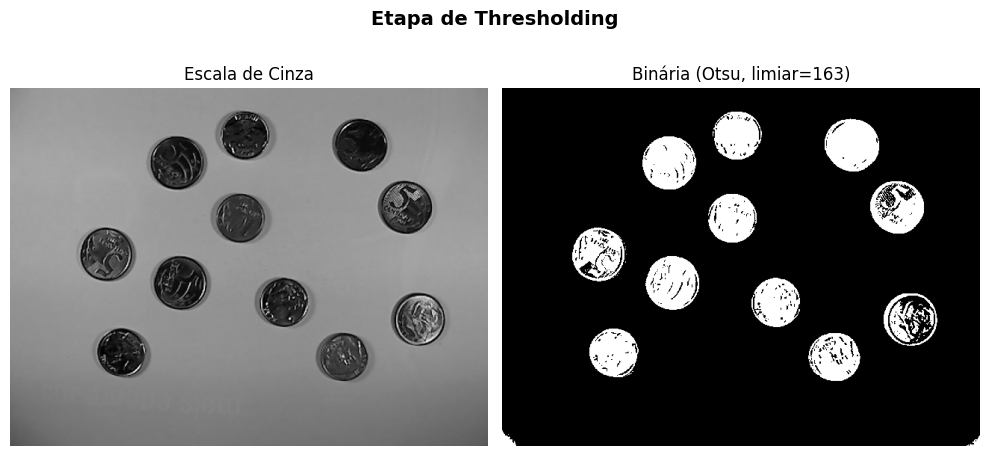

In [120]:
thresh_val, binr_demo = cv2.threshold(255 - img_gray_demo, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

#-------------------------------Plotando----------------------------------------
fig, axs = plt.subplots(1, 2, figsize=(10, 5))
fig.suptitle('Etapa de Thresholding', fontsize=14, fontweight='bold')

axs[0].imshow(img_gray_demo, cmap='gray')
axs[0].set_title('Escala de Cinza')
axs[0].axis('off')

axs[1].imshow(binr_demo, cmap='gray')
axs[1].set_title(f'Binária (Otsu, limiar={thresh_val:.0f})')
axs[1].axis('off')

plt.tight_layout()
plt.show()

###Etapa 3 - Abertura e Fechamento

Após a limiarização, ainda podem existir buracos nas moedas ou ruídos no fundo. Para resolver isso, utilizamos técnicas de morfologia matemática. O fechamento é utilizado para preencher os buracos e , em seguida, a abertura remove os ruídos.

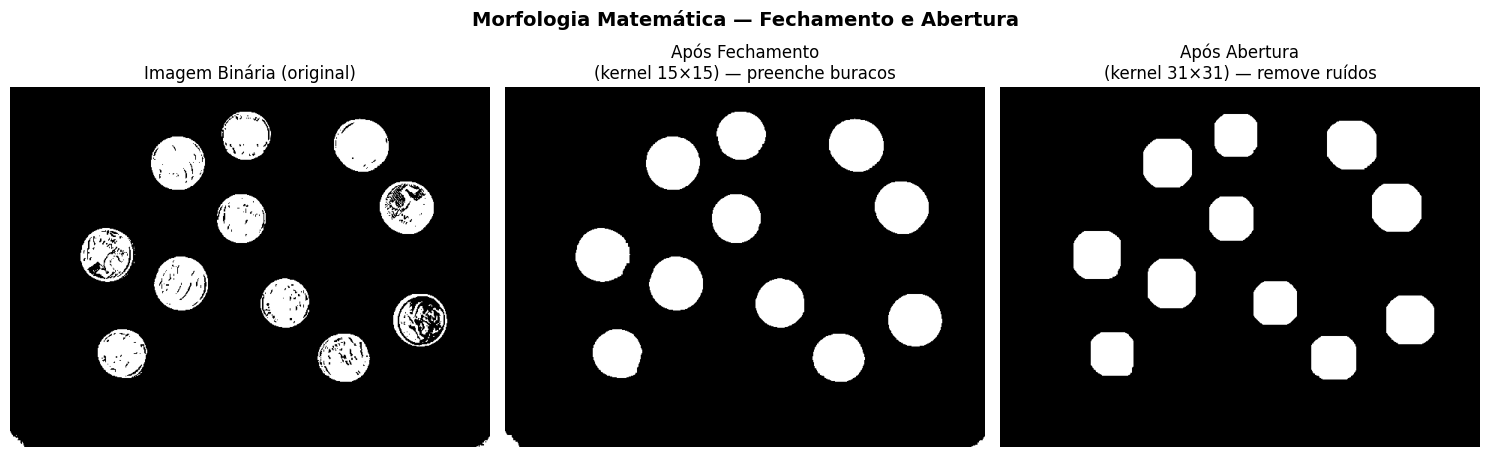

In [121]:
k_cl, k_op = 15, 31

kernel_cl = np.ones((k_cl, k_cl), np.uint8)
kernel_op = np.ones((k_op, k_op), np.uint8)

close = cv2.morphologyEx(binr_demo, cv2.MORPH_CLOSE, kernel_cl, iterations=1)
open = cv2.morphologyEx(close, cv2.MORPH_OPEN, kernel_op, iterations=1)

#-------------------------------Plotando----------------------------------------
fig, axs = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Morfologia Matemática — Fechamento e Abertura', fontsize=14, fontweight='bold')

axs[0].imshow(binr_demo, cmap='gray')
axs[0].set_title('Imagem Binária (original)')
axs[0].axis('off')

axs[1].imshow(close, cmap='gray')
axs[1].set_title(f'Após Fechamento\n(kernel {k_cl}×{k_cl}) — preenche buracos')
axs[1].axis('off')

axs[2].imshow(open, cmap='gray')
axs[2].set_title(f'Após Abertura\n(kernel {k_op}×{k_op}) — remove ruídos')
axs[2].axis('off')

plt.tight_layout()
plt.show()

###Etapa 4 - Identificação das moedas

Com a imagem processada, podemos identificar o que são moedas além de rotulá-las e contar quantas tem. Para isso, usamos a função "connectedComponentsWithStats" da biblioteca cv2, para identificar grupos de pixels brancos conectados entre si e atribuir rótulos à eles. Cada um desses grupos é uma moeda.

A função retorna o número de rótulos (n_labels), que representa a quantidade de moedas (mais o fundo, que fica com rótulo 0), os rótulos, estatísticas dos componentes, além das cordenadas dos centroides dos componentes.

Número de componentes encontrados (incluindo fundo): 12
Número de moedas detectadas: 11


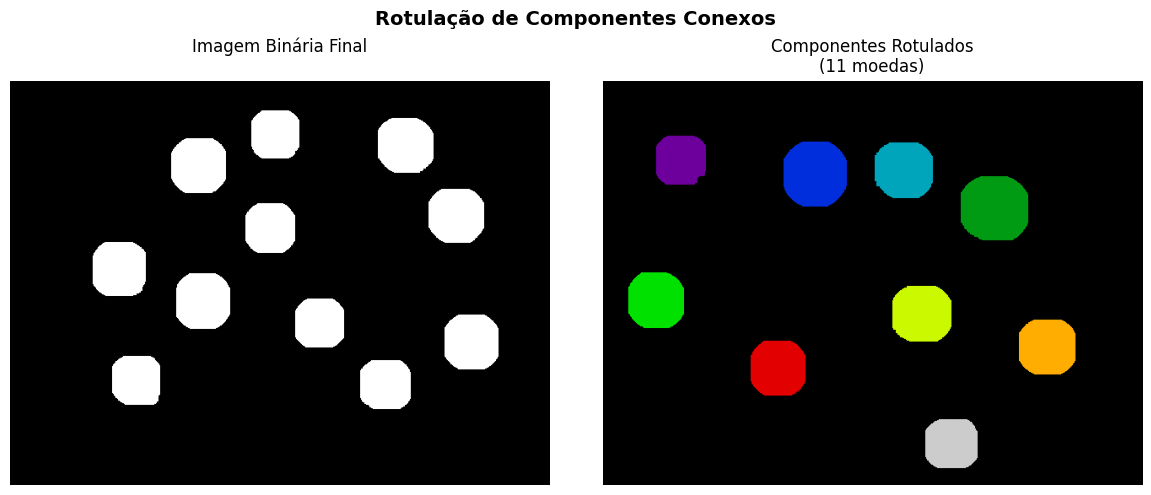

In [122]:
output = cv2.connectedComponentsWithStats(open, 4)

#-------------------------------Plotando----------------------------------------
print(f'Número de componentes encontrados (incluindo fundo): {output[0]}')
print(f'Número de moedas detectadas: {output[0] - 1}')

fig, axs = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Rotulação de Componentes Conexos\n', fontsize=14, fontweight='bold')

axs[0].imshow(open, cmap='gray')
axs[0].set_title('Imagem Binária Final\n')
axs[0].axis('off')

axs[1].imshow(labels, cmap='nipy_spectral')
axs[1].set_title(f'Componentes Rotulados\n({output[0]-1} moedas)')
axs[1].axis('off')

plt.tight_layout()
plt.show()

###Etapa 5 - Contagem do resultado

Com as moedas identificadas, a parte final é classificar cada uma e somar seus valores. Para isso, calculamos o tamanho de cada moeda em pixels, considerando que as moedas tem tamanhos diferentes.

O critério que foi usado foi o seguinte:

| Área (pixels) | Valor da moeda |
|:---:|:---:|
| < 3.500 px | **10 centavos** (menor) |
| 3.500 – 4.600 px | **5 centavos** (médio) |
| > 4.600 px | **25 centavos** (maior) |

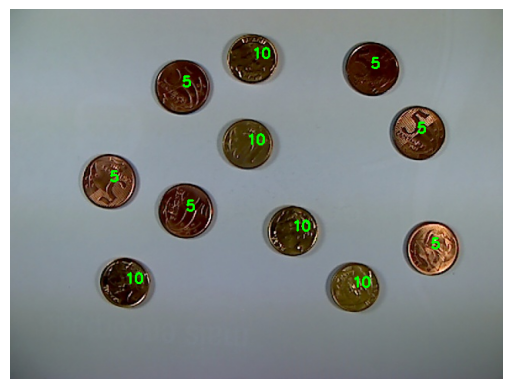

Imagem 80.jpg
Número de moedas 11
Valor total: 80


In [123]:
def calc_npixels_label(img, n_labels):
    """Conta o número de pixels de cada componente rotulado."""
    list_npixels = []
    for v in range(n_labels - 1):
        npixels = (img[img == v + 1] // (v + 1)).sum()
        list_npixels.append(npixels)
    return list_npixels

list_npixels = calc_npixels_label(output[1], output[0])

soma = 0
for n, p in enumerate(list_npixels):
  x = int(output[3][n+1][0])
  y = int(output[3][n+1][1])

  if p < 3500:
    soma += 10
    cv2.putText(img_demo, '10', (x, y), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 255, 0), 2)
  elif p > 4600:
    soma += 25
    cv2.putText(img_demo, '25', (x, y), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 255, 0), 2)
  else:
    soma += 5
    cv2.putText(img_demo, '5', (x, y), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 255, 0), 2)

#-------------------------------Plotando----------------------------------------
plt.imshow(img_demo)
plt.axis('off')
plt.show()

print('Imagem', filenames[numero_da_imagem])
print('Número de moedas', len(list_npixels))
print('Valor total:', soma)

Como resultado, obtemos uma imagem com o valor de cada moeda, uma contagem de quantas moedas tem, além do valor de sua soma total.

## Referências úteis:

---

### Documentação oficial
- [OpenCV — Thresholding](https://docs.opencv.org/4.x/d7/d4d/tutorial_py_thresholding.html)
- [OpenCV — Morphological Transformations](https://docs.opencv.org/4.x/d9/d61/tutorial_py_morphological_ops.html)
- [OpenCV — Connected Components](https://docs.opencv.org/4.x/d3/dc0/group__imgproc__shape.html#ga107a78bf7cd25dec05fb4dfc5c9e765f)

### Tutoriais e materiais complementares
- [PyImageSearch — Image Thresholding with OpenCV](https://pyimagesearch.com/2021/04/28/opencv-thresholding-cv2-threshold/)
- [PyImageSearch — Connected Component Labeling](https://pyimagesearch.com/2021/02/22/opencv-connected-component-labeling-and-analysis/)
- [Scikit-image — Morphological Operations](https://scikit-image.org/docs/stable/auto_examples/applications/plot_morphology.html)

###